In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.497635,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,-0.747766,0.0,0.600320,0.075008,0.231096
1,-0.473435,0.0,0.0,-1.0,0.0,1.0,-1.0,-1.0,1.0,0.159774,0.0,-0.690705,-0.466877,-0.387041
2,-0.113739,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,1.0,0.610629,1.0,-0.308082,0.641923,0.210342
3,0.826312,0.0,0.0,-1.0,0.0,1.0,-1.0,-1.0,1.0,0.494088,0.0,-0.987020,-0.399206,-0.398539
4,0.596634,0.0,0.0,-1.0,0.0,1.0,-1.0,-1.0,1.0,1.007387,0.0,-0.641777,-0.293211,-0.315926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.747766,0.0,-0.109388,-0.294765,-0.236855
135,0.671213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.747766,1.0,-0.399297,1.027319,0.352293
136,-0.235838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.560275,0.0,0.518153,-0.059989,0.075327
137,0.421516,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.620942,1.0,-0.353490,0.464201,0.118722


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

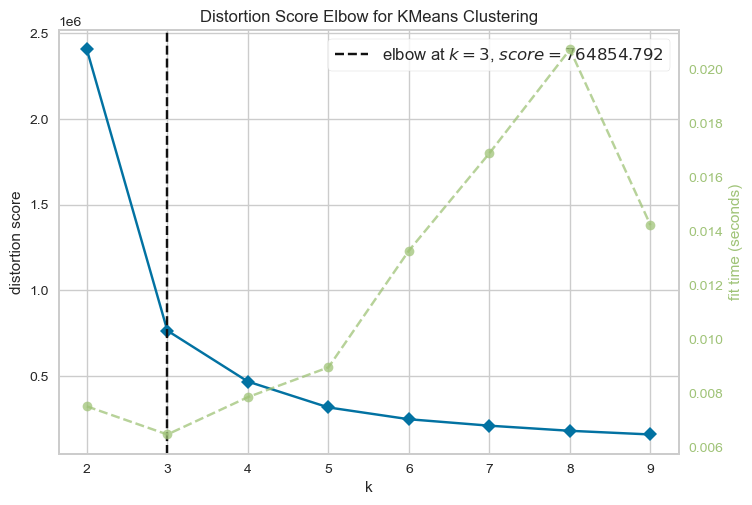

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 3  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: pack_years
Correlation coefficient: 0.5694924435077031


1
Most correlated column: TLG
Correlation coefficient: 2.3100008968428023


2
Most correlated column: hpv_related
Correlation coefficient: 0.2460640183505367




In [22]:
selected_features

['pack_years', 'TLG', 'hpv_related']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [26]:
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Standardize X_new, the new data with the selected features only 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [27]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [28]:
X_new

,pack_years,TLG,hpv_related
0,0.000000,86.228420,0.0
1,27.404795,7.040100,0.0
2,41.019178,83.569669,0.0
3,37.500000,5.567091,0.0
4,53.000000,16.150550,0.0
...,...,...,...
134,0.000000,26.280140,1.0
135,0.000000,101.754834,1.0
136,39.498630,66.273201,1.0
137,71.527397,71.832443,1.0


In [29]:
X_new_std

,pack_years,TLG,hpv_related
0,-0.747766,0.231096,0.0
1,0.159774,-0.387041,0.0
2,0.610629,0.210342,0.0
3,0.494088,-0.398539,0.0
4,1.007387,-0.315926,0.0
...,...,...,...
134,-0.747766,-0.236855,1.0
135,-0.747766,0.352293,1.0
136,0.560275,0.075327,1.0
137,1.620942,0.118722,1.0


In [30]:
MAASTRO_new

,pack_years,TLG,hpv_related
0,0,263.611623,1
1,20,36.980700,0
2,6,74.636342,0
3,45,46.791979,0
4,59,107.637514,1
...,...,...,...
94,55,144.490782,0
95,174,69.214868,0
96,0,102.594274,1
97,0,103.229492,1


In [31]:
MAASTRO_new_std

,pack_years,TLG,hpv_related
0,-0.747766,1.615732,1
1,-0.085444,-0.153327,0
2,-0.549070,0.140609,0
3,0.742458,-0.076742,0
4,1.206084,0.398213,1
...,...,...,...
94,1.073619,0.685886,0
95,5.014436,0.098289,0
96,-0.747766,0.358846,1
97,-0.747766,0.363804,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [32]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:00:53,835] A new study created in memory with name: no-name-e4b825c5-1504-413b-b397-b50fc95a8f1b


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:00:53,997] A new study created in memory with name: no-name-ec6ca196-ebbd-4c56-bba5-46cc9516becb


Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 17:00:53,994] Trial 0 finished with value: 0.6348970271032044 and parameters: {}. Best is trial 0 with value: 0.6348970271032044.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6348970271032044], datetime_start=datetime.datetime(2024, 4, 13, 17, 0, 53, 911387), datetime_complete=datetime.datetime(2024, 4, 13, 17, 0, 53, 994438), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6348970271032044


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21958661594893134
Fold 2 IBS: 0.23663931577837308
Fold 3 IBS: 0.20100118832841965
Fold 4 IBS: 0.26468132252122445
Fold 5 IBS: 0.21176963693288944
[I 2024-04-13 17:00:54,110] Trial 0 finished with value: 0.2267356159019676 and parameters: {}. Best is trial 0 with value: 0.2267356159019676.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2267356159019676], datetime_start=datetime.datetime(2024, 4, 13, 17, 0, 54, 12790), datetime_complete=datetime.datetime(2024, 4, 13, 17, 0, 54, 110667), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2267356159019676


In [33]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [34]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.635
train_ibs:  0.227


#### Test

In [35]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [36]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.598
IBS score: 0.24


In [37]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [38]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [39]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:00:55,594] A new study created in memory with name: no-name-28b776ba-018c-4b12-b0bb-1992142d0ab9


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:00:55,663] A new study created in memory with name: no-name-46294361-4b29-4ea3-b152-90550a822273


Fold 1 C-index: 0.6653386454183267
Fold 2 C-index: 0.5251937984496124
Fold 3 C-index: 0.6127659574468085
Fold 4 C-index: 0.4543726235741445
Fold 5 C-index: 0.6781115879828327
[I 2024-04-13 17:00:55,661] Trial 0 finished with value: 0.5871565225743449 and parameters: {}. Best is trial 0 with value: 0.5871565225743449.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5871565225743449], datetime_start=datetime.datetime(2024, 4, 13, 17, 0, 55, 611827), datetime_complete=datetime.datetime(2024, 4, 13, 17, 0, 55, 661246), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5871565225743449


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709557228292
Fold 2 IBS: 0.23203988483138108
Fold 3 IBS: 0.228981863802055
Fold 4 IBS: 0.24197478455226282
Fold 5 IBS: 0.22939558797739115
[I 2024-04-13 17:00:55,735] Trial 0 finished with value: 0.23592784334707462 and parameters: {}. Best is trial 0 with value: 0.23592784334707462.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784334707462], datetime_start=datetime.datetime(2024, 4, 13, 17, 0, 55, 675693), datetime_complete=datetime.datetime(2024, 4, 13, 17, 0, 55, 735106), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784334707462


In [40]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [41]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.587
train_ibs:  0.236


#### Test

In [42]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [43]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.546


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [44]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [45]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:00:56,343] A new study created in memory with name: no-name-068689fc-8c1b-4c3e-9fc6-ea49aed06f7d


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:00:56,455] A new study created in memory with name: no-name-1450b46b-0b16-48af-8604-37d2d76e8a73


Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:00:56,453] Trial 0 finished with value: 0.6350633777037301 and parameters: {}. Best is trial 0 with value: 0.6350633777037301.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6350633777037301], datetime_start=datetime.datetime(2024, 4, 13, 17, 0, 56, 356857), datetime_complete=datetime.datetime(2024, 4, 13, 17, 0, 56, 452997), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6350633777037301


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21965459153194536
Fold 2 IBS: 0.23626397770226165
Fold 3 IBS: 0.20148626587626273
Fold 4 IBS: 0.26467199817214887
Fold 5 IBS: 0.2118677068587341
[I 2024-04-13 17:00:56,578] Trial 0 finished with value: 0.2267889080282705 and parameters: {}. Best is trial 0 with value: 0.2267889080282705.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2267889080282705], datetime_start=datetime.datetime(2024, 4, 13, 17, 0, 56, 467779), datetime_complete=datetime.datetime(2024, 4, 13, 17, 0, 56, 578809), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2267889080282705


In [46]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [47]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.635
train_ibs:  0.227


#### Test

In [48]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [49]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.599


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.239


In [50]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [51]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:00:57,094] A new study created in memory with name: no-name-70a1b8be-ff68-4df3-ade7-0e1ac2757abe


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.575107296137339
[I 2024-04-13 17:00:57,206] Trial 0 finished with value: 0.6342050086050177 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6342050086050177.
Fold 1 C-index: 0.6932270916334662
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.5879828326180258
[I 2024-04-13 17:00:57,297] Trial 1 finished with value: 0.5934704647718321 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6342050086050177.
Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.5836909871244635
[I 2024-04-13 17:00:57,389] Trial 2 finished with value: 0.5918152829241157 and parameters: {'l1_ratio': 0.22692876841884668}

Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.5879828326180258
[I 2024-04-13 17:00:59,560] Trial 25 finished with value: 0.637576928650159 and parameters: {'l1_ratio': 0.347742403809294}. Best is trial 9 with value: 0.637576928650159.
Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.44866920152091255
Fold 5 C-index: 0.5836909871244635
[I 2024-04-13 17:00:59,649] Trial 26 finished with value: 0.5918152829241157 and parameters: {'l1_ratio': 0.27012137393375085}. Best is trial 9 with value: 0.637576928650159.
Fold 1 C-index: 0.6932270916334662
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.575107296137339
[I 2024-04-13 17:00:59,748] Trial 27 finished with value: 0.6350018213540217 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 9 with value: 0.637576928650159.
Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.51744186

Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:01:01,826] Trial 49 finished with value: 0.6358601904527341 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 9 with value: 0.637576928650159.
Fold 1 C-index: 0.6932270916334662
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.575107296137339
[I 2024-04-13 17:01:01,920] Trial 50 finished with value: 0.6350018213540217 and parameters: {'l1_ratio': 0.556147470734502}. Best is trial 9 with value: 0.637576928650159.
Fold 1 C-index: 0.6932270916334662
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6692015209125475
Fold 5 C-index: 0.5879828326180258
[I 2024-04-13 17:01:02,029] Trial 51 finished with value: 0.637576928650159 and parameters: {'l1_ratio': 0.3305827397566983}. Best is trial 9 with value: 0.637576928650159.
Fold 1 C-index: 0.6932270916334662
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.66382978

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.21964650355410795
Fold 2 IBS: 0.23631653921859325
Fold 3 IBS: 0.20144752946963376
Fold 4 IBS: 0.2646345452485655
Fold 5 IBS: 0.21148555969395857
[I 2024-04-13 17:01:06,501] Trial 0 finished with value: 0.2267061354369718 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.2267061354369718.
Fold 1 IBS: 0.21962991737174783
Fold 2 IBS: 0.23645513510231977
Fold 3 IBS: 0.20139184648671565
Fold 4 IBS: 0.2711903560807151
Fold 5 IBS: 0.2110135297205186
[I 2024-04-13 17:01:06,599] Trial 1 finished with value: 0.22793615695240343 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.2267061354369718.
Fold 1 IBS: 0.21962974057334841
Fold 2 IBS: 0.23648858132714914
Fold 3 IBS: 0.20139127441831142
Fold 4 IBS: 0.2676448102491281
Fold 5 IBS: 0.21090878281916187
[I 2024-04-13 17:01:06,697] Trial 2 finished with value: 0.2272126378774198 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.2267061354369718.

Fold 3 IBS: 0.20140265150859163
Fold 4 IBS: 0.2724245661023861
Fold 5 IBS: 0.21103783042232233
[I 2024-04-13 17:01:08,948] Trial 25 finished with value: 0.22819106142658113 and parameters: {'l1_ratio': 0.3118045712140933}. Best is trial 12 with value: 0.22662334542283813.
Fold 1 IBS: 0.21962353593340017
Fold 2 IBS: 0.23262242179687112
Fold 3 IBS: 0.22508308088395856
Fold 4 IBS: 0.2579451306376287
Fold 5 IBS: 0.22504037349940206
[I 2024-04-13 17:01:09,015] Trial 26 finished with value: 0.23206290855025213 and parameters: {'l1_ratio': 0.12029904924344553}. Best is trial 12 with value: 0.22662334542283813.
Fold 1 IBS: 0.21964805720553907
Fold 2 IBS: 0.23629077422559064
Fold 3 IBS: 0.20145373715031437
Fold 4 IBS: 0.2646480955433847
Fold 5 IBS: 0.2116071093668294
[I 2024-04-13 17:01:09,115] Trial 27 finished with value: 0.22672955469833161 and parameters: {'l1_ratio': 0.7997456341249385}. Best is trial 12 with value: 0.22662334542283813.
Fold 1 IBS: 0.21962979290407783
Fold 2 IBS: 0.2364885

Fold 2 IBS: 0.23644567502071373
Fold 3 IBS: 0.20141460874080921
Fold 4 IBS: 0.2645790710659802
Fold 5 IBS: 0.2110647040338216
[I 2024-04-13 17:01:11,603] Trial 51 finished with value: 0.22662751036053122 and parameters: {'l1_ratio': 0.33938951836194703}. Best is trial 41 with value: 0.22662018262683709.
Fold 1 IBS: 0.21963548336154953
Fold 2 IBS: 0.23644404255263832
Fold 3 IBS: 0.20142765489467057
Fold 4 IBS: 0.2645738187935839
Fold 5 IBS: 0.21102064675364351
[I 2024-04-13 17:01:11,713] Trial 52 finished with value: 0.22662032927121717 and parameters: {'l1_ratio': 0.3256829217653613}. Best is trial 41 with value: 0.22662018262683709.
Fold 1 IBS: 0.2196305359233214
Fold 2 IBS: 0.23646992281329668
Fold 3 IBS: 0.20139597218949262
Fold 4 IBS: 0.27099185937449705
Fold 5 IBS: 0.21099945867042202
[I 2024-04-13 17:01:11,819] Trial 53 finished with value: 0.22789754979420596 and parameters: {'l1_ratio': 0.28238102650530905}. Best is trial 41 with value: 0.22662018262683709.
Fold 1 IBS: 0.219626

Fold 1 IBS: 0.21963227821526568
Fold 2 IBS: 0.23645807827870255
Fold 3 IBS: 0.20140707816930356
Fold 4 IBS: 0.2722218119533819
Fold 5 IBS: 0.2110230981695324
[I 2024-04-13 17:01:14,333] Trial 76 finished with value: 0.22814846895723723 and parameters: {'l1_ratio': 0.3073726537352946}. Best is trial 41 with value: 0.22662018262683709.
Fold 1 IBS: 0.2196349581696308
Fold 2 IBS: 0.23643194322753955
Fold 3 IBS: 0.201423696151819
Fold 4 IBS: 0.2645842180024319
Fold 5 IBS: 0.2111081503532867
[I 2024-04-13 17:01:14,448] Trial 77 finished with value: 0.2266365931809416 and parameters: {'l1_ratio': 0.3740004040739309}. Best is trial 41 with value: 0.22662018262683709.
Fold 1 IBS: 0.21963262597181904
Fold 2 IBS: 0.2364681310125321
Fold 3 IBS: 0.20140964227967703
Fold 4 IBS: 0.2703446075020569
Fold 5 IBS: 0.21095297166342697
[I 2024-04-13 17:01:14,555] Trial 78 finished with value: 0.2277615956859024 and parameters: {'l1_ratio': 0.27037906172876325}. Best is trial 41 with value: 0.226620182626837

In [52]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [53]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.638
train_ibs:  0.227


#### Test

In [54]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [55]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.3921783064423311)

test_cindex : 0.598


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.355013091809259)

test_ibs:  0.24


In [56]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [57]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:01:17,101] A new study created in memory with name: no-name-156dd47b-93f8-42c9-a646-31b4fcf72b0c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6772908366533864
Fold 2 C-index: 0.5794573643410853
Fold 3 C-index: 0.6127659574468085
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.5493562231759657
[I 2024-04-13 17:01:18,153] Trial 0 finished with value: 0.6198957493272514 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6198957493272514.
Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.627906976744186
Fold 3 C-index: 0.6574468085106383
Fold 4 C-index: 0.6711026615969582
Fold 5 C-index: 0.5772532188841202
[I 2024-04-13 17:01:18,918] Trial 1 finished with value: 0.6334351602388141 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.6759656652360515
[I 2024-04-13 17:01:27,093] Trial 15 finished with value: 0.7136966503360582 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 9, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 56, 'oob_score': True, 'max_samples': 0.9840854477573787, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.0921839163034627, 'warm_start': True}. Best is trial 15 with value: 0.7136966503360582.
Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5193798449612403
Fold 3 C-index: 0.5638297872340425
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.6545064377682404
[I 2024-04-13 17:01:27,150] Trial 16 finished with value: 0.62364943549453 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 8, 'n_estimators': 4, 'oob_score': True, 'max_samples': 0.44827686549014745, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.09517468010039555, 'warm_start': True}. Best is trial 15 with value: 0.7136966503360582.
F

Fold 3 C-index: 0.6510638297872341
Fold 4 C-index: 0.6482889733840305
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:01:30,087] Trial 30 finished with value: 0.6399497846106897 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 6, 'min_samples_leaf': 7, 'max_depth': 1, 'n_estimators': 153, 'oob_score': True, 'max_samples': 0.5042840686605841, 'max_features': None, 'min_weight_fraction_leaf': 0.2486312042554125, 'warm_start': True}. Best is trial 19 with value: 0.7197288774380359.
Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.8021276595744681
Fold 4 C-index: 0.7756653992395437
Fold 5 C-index: 0.7103004291845494
[I 2024-04-13 17:01:30,295] Trial 31 finished with value: 0.7246868590623887 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 4, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 97, 'oob_score': True, 'max_samples': 0.7237125084897875, 'max_features': None, 'min_weight_fraction_leaf': 0.041814381732131, 'warm_

...

Fold 1 IBS: 0.2465766667348331
Fold 2 IBS: 0.23212304244803478
Fold 3 IBS: 0.22958854783579488
Fold 4 IBS: 0.2415918421168299
Fold 5 IBS: 0.23025798914741616
[I 2024-04-13 17:02:20,820] Trial 32 finished with value: 0.23602761765658178 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 2, 'n_estimators': 219, 'oob_score': False, 'max_samples': 0.9059629922358273, 'max_features': None, 'min_weight_fraction_leaf': 0.464009913986499}. Best is trial 12 with value: 0.2174586863617069.
Fold 1 IBS: 0.21974536488640078
Fold 2 IBS: 0.2292375823834431
Fold 3 IBS: 0.23087439002520285
Fold 4 IBS: 0.22606200338363028
Fold 5 IBS: 0.21549820209886905
[I 2024-04-13 17:02:21,720] Trial 33 finished with value: 0.22428350855550921 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4, 'n_estimators': 263, 'oob_score': False, 'max_samples': 0.9963934017185284, 'max_features': None, 'min_weight_fraction_leaf':

Fold 1 IBS: 0.22954297364907345
Fold 2 IBS: 0.22541321026320577
Fold 3 IBS: 0.21498990522680206
Fold 4 IBS: 0.22074580843033642
Fold 5 IBS: 0.2256877008748603
[I 2024-04-13 17:02:33,479] Trial 48 finished with value: 0.22327591968885557 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 19, 'min_samples_leaf': 7, 'max_depth': 4, 'n_estimators': 356, 'oob_score': True, 'max_samples': 0.8663168998271439, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.10113764894009272}. Best is trial 12 with value: 0.2174586863617069.
Fold 1 IBS: 0.22465425488846616
Fold 2 IBS: 0.2232529114363708
Fold 3 IBS: 0.20971833155966707
Fold 4 IBS: 0.22032599934179872
Fold 5 IBS: 0.21732614451039353
[I 2024-04-13 17:02:34,548] Trial 49 finished with value: 0.21905552834733927 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 20, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 270, 'oob_score': True, 'max_samples': 0.8459565404966409, 'max_features': 'auto', 'min_weight_fraction_le

Fold 1 IBS: 0.22582734698711443
Fold 2 IBS: 0.22809327737163398
Fold 3 IBS: 0.2154709346963749
Fold 4 IBS: 0.22133421709000317
Fold 5 IBS: 0.22321338550774886
[I 2024-04-13 17:02:57,628] Trial 64 finished with value: 0.22278783233057511 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 1, 'max_depth': 3, 'n_estimators': 338, 'oob_score': True, 'max_samples': 0.7584685198296572, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.12264172164899388}. Best is trial 12 with value: 0.2174586863617069.
Fold 1 IBS: 0.22636063765903483
Fold 2 IBS: 0.22567909586629714
Fold 3 IBS: 0.20884569832503236
Fold 4 IBS: 0.21971786668815085
Fold 5 IBS: 0.2195660934953674
[I 2024-04-13 17:02:59,285] Trial 65 finished with value: 0.22003387840677652 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 370, 'oob_score': True, 'max_samples': 0.6368394778619931, 'max_features': 'log2', 'min_weight_fraction_le

Fold 5 IBS: 0.22949463551007857
[I 2024-04-13 17:03:16,682] Trial 79 finished with value: 0.23593753662017242 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 229, 'oob_score': True, 'max_samples': 0.12074719353470553, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.030282567726053682}. Best is trial 12 with value: 0.2174586863617069.
Fold 1 IBS: 0.24474879174286496
Fold 2 IBS: 0.2699729290718033
Fold 3 IBS: 0.26550905743252157
Fold 4 IBS: 0.19815639877833147
Fold 5 IBS: 0.22600800968404186
[I 2024-04-13 17:03:16,768] Trial 80 finished with value: 0.2408790373419126 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 3, 'n_estimators': 2, 'oob_score': True, 'max_samples': 0.8763758053948292, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.07211152722867167}. Best is trial 12 with value: 0.2174586863617069.
Fold 1 IBS: 0.2300556276603225
Fold 2 IBS: 0.2233145

Fold 1 IBS: 0.2248882635805953
Fold 2 IBS: 0.224709374526936
Fold 3 IBS: 0.20359390785080134
Fold 4 IBS: 0.21652723881771557
Fold 5 IBS: 0.21419411225557072
[I 2024-04-13 17:03:38,763] Trial 95 finished with value: 0.21678257940632378 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 2, 'n_estimators': 283, 'oob_score': True, 'max_samples': 0.9976411612743514, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.03593335728901002}. Best is trial 95 with value: 0.21678257940632378.
Fold 1 IBS: 0.24110358617092542
Fold 2 IBS: 0.23310811743828555
Fold 3 IBS: 0.2080661076081253
Fold 4 IBS: 0.2249804142415811
Fold 5 IBS: 0.23367881411486546
[I 2024-04-13 17:03:40,316] Trial 96 finished with value: 0.22818740791475656 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 4, 'n_estimators': 304, 'oob_score': True, 'max_samples': 0.9816459196014407, 'max_features': 'log2', 'min_weight_fraction_leaf':

In [58]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [59]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.807
train_ibs:  0.217


#### Test

In [60]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [61]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=15, max_features='log2', max_leaf_nodes=18,
                     max_samples=0.9337821363025328, min_samples_leaf=1,
                     min_samples_split=8,
                     min_weight_fraction_leaf=0.017481844155492175,
                     n_estimators=451, random_state=123, warm_start=True)

test_cindex:  0.589


RandomSurvivalForest(max_depth=2, max_features='log2', max_leaf_nodes=20,
                     max_samples=0.9976411612743514, min_samples_leaf=1,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.03593335728901002,
                     n_estimators=283, oob_score=True, random_state=123)

test_ibs:  0.218


In [62]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [63]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:03:47,413] A new study created in memory with name: no-name-40c673c6-7eb1-42c2-8551-b879ebdac09f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6533864541832669
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7893617021276595
Fold 4 C-index: 0.7357414448669202
Fold 5 C-index: 0.6566523605150214
[I 2024-04-13 17:03:47,931] Trial 0 finished with value: 0.7011369194703565 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7011369194703565.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:03:48,767] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.6932270916334662
Fold 2 C-index: 0.6337209302325582
Fold 3 C-index: 0.7170212765957447
Fold 4 C-index: 0.714828897338403
Fold 5 C-index: 0.5879828326180258
[I 2024-04-13 17:03:58,581] Trial 15 finished with value: 0.6693562056836395 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7047783687812841.
Fold 1 C-index: 0.6912350597609562
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.6829787234042554
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.5815450643776824
[I 2024-04-13 17:03:59,073] Trial 16 finished with value: 0.6482331501198914 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.8297872340425532
Fold 4 C-index: 0.779467680608365
Fold 5 C-index: 0.7854077253218884
[I 2024-04-13 17:04:06,224] Trial 30 finished with value: 0.7412630508643226 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 406, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.9249924371154266, 'min_weight_fraction_leaf': 0.001306576414643712}. Best is trial 30 with value: 0.7412630508643226.
Fold 1 C-index: 0.6374501992031872
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.8297872340425532
Fold 4 C-index: 0.7870722433460076
Fold 5 C-index: 0.776824034334764
[I 2024-04-13 17:04:06,661] Trial 31 finished with value: 0.7426608507124342 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 403, 'oob_score': False, 'warm_start': True, 'max_features': 

...

Fold 2 IBS: 0.23138224028410745
Fold 3 IBS: 0.22929884260547317
Fold 4 IBS: 0.24085895567463228
Fold 5 IBS: 0.22713508563579154
[I 2024-04-13 17:05:39,341] Trial 30 finished with value: 0.23497279398547083 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 7, 'min_samples_leaf': 18, 'max_depth': 9, 'n_estimators': 126, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.606610485106031, 'min_weight_fraction_leaf': 0.2917886569515737}. Best is trial 19 with value: 0.21659869324465805.
Fold 1 IBS: 0.2227291679738252
Fold 2 IBS: 0.22949739345716264
Fold 3 IBS: 0.2063070208243304
Fold 4 IBS: 0.21712926004815514
Fold 5 IBS: 0.21233596806290483
[I 2024-04-13 17:05:39,826] Trial 31 finished with value: 0.21759976207327564 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 2, 'min_samples_leaf': 19, 'max_depth': 6, 'n_estimators': 78, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7486316031693021, 'min_weight_fractio

Fold 1 IBS: 0.2228087031388661
Fold 2 IBS: 0.2288916256811506
Fold 3 IBS: 0.20785224776272046
Fold 4 IBS: 0.2192530532844952
Fold 5 IBS: 0.21180371105463966
[I 2024-04-13 17:05:47,562] Trial 45 finished with value: 0.2181218681843744 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 6, 'min_samples_leaf': 11, 'max_depth': 11, 'n_estimators': 49, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7843312730909937, 'min_weight_fraction_leaf': 0.21599021570343435}. Best is trial 19 with value: 0.21659869324465805.
Fold 1 IBS: 0.24621764012533692
Fold 2 IBS: 0.2321920010969571
Fold 3 IBS: 0.22949852891672798
Fold 4 IBS: 0.24147448523123607
Fold 5 IBS: 0.23033851674318997
[I 2024-04-13 17:05:50,201] Trial 46 finished with value: 0.23594423442268958 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 13, 'min_samples_leaf': 14, 'max_depth': 6, 'n_estimators': 487, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.536827

Fold 4 IBS: 0.22038855787094935
Fold 5 IBS: 0.21230130929907046
[I 2024-04-13 17:06:01,554] Trial 60 finished with value: 0.21857174070805466 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 3, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 26, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.8649288483579932, 'min_weight_fraction_leaf': 0.23244080855036578}. Best is trial 19 with value: 0.21659869324465805.
Fold 1 IBS: 0.22282264972589091
Fold 2 IBS: 0.22843784844670903
Fold 3 IBS: 0.20683510043032505
Fold 4 IBS: 0.21564424466300827
Fold 5 IBS: 0.21162484922732586
[I 2024-04-13 17:06:01,801] Trial 61 finished with value: 0.21707293849865184 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 9, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 12, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9314102267448461, 'min_weight_fraction_leaf': 0.20688226158797565}. Best is trial 19 with value: 0.

Fold 1 IBS: 0.22021733284335115
Fold 2 IBS: 0.2306594992324283
Fold 3 IBS: 0.21317627014544116
Fold 4 IBS: 0.21990854433775162
Fold 5 IBS: 0.21310958570043348
[I 2024-04-13 17:06:05,158] Trial 75 finished with value: 0.21941424645188112 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 35, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.5607958100345728, 'min_weight_fraction_leaf': 0.07347514467107003}. Best is trial 73 with value: 0.21647533424492077.
Fold 1 IBS: 0.23376943113897122
Fold 2 IBS: 0.23186963023821708
Fold 3 IBS: 0.20490132549428017
Fold 4 IBS: 0.22770745732731987
Fold 5 IBS: 0.22103923423507074
[I 2024-04-13 17:06:05,305] Trial 76 finished with value: 0.2238574156867718 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 8, 'min_samples_leaf': 7, 'max_depth': 4, 'n_estimators': 2, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.626856318

Fold 1 IBS: 0.22746240615395333
Fold 2 IBS: 0.2265622511319443
Fold 3 IBS: 0.20370689916561482
Fold 4 IBS: 0.2159669990810382
Fold 5 IBS: 0.21307556209678843
[I 2024-04-13 17:06:15,566] Trial 90 finished with value: 0.21735482352586782 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 3, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.6224128059974403, 'min_weight_fraction_leaf': 0.14080848588433345}. Best is trial 73 with value: 0.21647533424492077.
Fold 1 IBS: 0.22290318641282408
Fold 2 IBS: 0.22737532333446397
Fold 3 IBS: 0.20674826854492134
Fold 4 IBS: 0.2160546644577947
Fold 5 IBS: 0.2114495146032231
[I 2024-04-13 17:06:15,763] Trial 91 finished with value: 0.21690619147064547 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 15, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.959305201461

In [64]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [65]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.756
train_ibs:  0.216


#### Test

In [66]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [67]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=10, max_leaf_nodes=17,
                   max_samples=0.5217447371899543, min_samples_leaf=1,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.016610960812108107,
                   n_estimators=473, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.622


ExtraSurvivalTrees(max_depth=4, max_features=None, max_leaf_nodes=10,
                   max_samples=0.5224430423416083, min_samples_leaf=8,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.17188602714208834, n_estimators=2,
                   oob_score=True, random_state=123, warm_start=True)

IBS: 0.222


In [68]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [69]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:06:18,831] A new study created in memory with name: no-name-97821104-4cde-4b61-98ac-ff8ef25f6bfd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:06:29,268] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:06:35,081] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:09:37,265] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 12 with value: 0.6382377080853077.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:10:09,546] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squar

Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:17:22,545] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 12 with value: 0.6382377080853077.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:18:23,544] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:08:11,900] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 22 with value: 0.23565924399848764.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 19:08:26,832] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435,

Fold 3 IBS: 0.22727523304221864
Fold 4 IBS: 0.24076522208220275
Fold 5 IBS: 0.22740421946383169
[I 2024-04-13 19:26:28,781] Trial 55 finished with value: 0.23399549325890873 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 53 with value: 0.2330852638828736.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 19:28:33,331] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.030884976740

Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 20:11:56,911] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6883221930691388, 'learning_rate': 0.043486677645014335, 'dropout_rate': 0.17314117987651884, 'n_estimators': 300, 'criterion': 'friedman_mse', 'ccp_alpha': 1.392319704490283, 'min_weight_fraction_leaf': 0.3364958462902864, 'max_features': None, 'min_impurity_decrease': 0.0002596209104718211, 'validation_fraction': 0.3924562181388663, 'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 15}. Best is trial 65 with value: 0.23254399319495564.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:13:18,450] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6123270626634933, 'learning_rate': 0.03766085593505888, 'dropout_rate': 0.1211076796

Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:25:47,110] Trial 77 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7208569038924214, 'learning_rate': 0.05192053710008563, 'dropout_rate': 0.14722481204936977, 'n_estimators': 278, 'criterion': 'friedman_mse', 'ccp_alpha': 1.2475932363504658, 'min_weight_fraction_leaf': 0.3158320981928932, 'max_features': 1, 'min_impurity_decrease': 0.00012102044847110188, 'validation_fraction': 0.5276751192385221, 'min_samples_split': 6, 'max_leaf_nodes': 6, 'min_samples_leaf': 11, 'max_depth': 12}. Best is trial 65 with value: 0.23254399319495564.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:27:37,892] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6246097794699133, 'learning_rate': 0.04647316253399379, 'dropout_rate': 0.2683524876236738, 'n_estimators': 390, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:45:59,555] Trial 89 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7062934300236606, 'learning_rate': 0.04049073641133963, 'dropout_rate': 0.10286028062555917, 'n_estimators': 321, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5179367484462377, 'min_weight_fraction_leaf': 0.3812326539458533, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.43928293695272114, 'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 11}. Best is trial 65 with value: 0.23254399319495564.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 20:47:50,545] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subs

In [70]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [71]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.65
train_ibs:  0.233


#### Test

In [72]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [73]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.011421239281947375,
                                 dropout_rate=0.8532026365391747,
                                 learning_rate=0.06843718884972436,
                                 max_depth=15, max_features='sqrt',
                                 max_leaf_nodes=14,
                                 min_impurity_decrease=0.00025810065693550576,
                                 min_samples_leaf=19, min_samples_split=11,
                                 min_weight_fraction_leaf=0.1722499331193231,
                                 n_estimators=150, random_state=123,
                                 subsample=0.751975475615093,
                                 validation_fraction=0.49972956116746087)

C-index score: 0.622


GradientBoostingSurvivalAnalysis(ccp_alpha=0.0027463880859729187,
                                 dropout_rate=0.16871798720386325,
                                 learning_rate=0.04324945527987548,
                                 max_depth=15, max_leaf_nodes=5,
                                 min_impurity_decrease=0.0005159101285841248,
                                 min_samples_leaf=7, min_samples_split=3,
                                 min_weight_fraction_leaf=0.3355883872029622,
                                 n_estimators=300, random_state=123,
                                 subsample=0.6891090397922855,
                                 validation_fraction=0.4525371458863552)

IBS: 0.225


In [74]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [75]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 20:59:44,473] A new study created in memory with name: no-name-772a0d05-459d-4969-b872-027fec8acfc5


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 20:59:46,492] Trial 0 finished with value: 0.5620513847065254 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5620513847065254.
Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5531914893617021
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 21:00:03,213] Trial 1 finished with value: 0.5601049402441033 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5620513847065254.
Fold 1 C-index: 0.6613545816733067
Fold 2 C-index: 0.501937984496124
Fold 3 C-index: 0.5574468085106383
Fold 

Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5135658914728682
Fold 3 C-index: 0.5617021276595745
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 21:02:07,090] Trial 19 finished with value: 0.5932992205534318 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.34721836740782674, 'n_estimators': 49, 'learning_rate': 0.08481939723114393}. Best is trial 18 with value: 0.6266416258616478.
Fold 1 C-index: 0.6772908366533864
Fold 2 C-index: 0.5174418604651163
Fold 3 C-index: 0.5872340425531914
Fold 4 C-index: 0.6577946768060836
Fold 5 C-index: 0.6738197424892703
[I 2024-04-13 21:02:08,843] Trial 20 finished with value: 0.6227162317934096 and parameters: {'subsample': 0.179916923106687, 'dropout_rate': 0.7430916480391414, 'n_estimators': 112, 'learning_rate': 0.09584338883210179}. Best is trial 18 with value: 0.6266416258616478.
Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5096899224806202
Fold 3 C-index: 0.6170212765957447
F

Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5155038759689923
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.6539923954372624
Fold 5 C-index: 0.6781115879828327
[I 2024-04-13 21:02:49,464] Trial 38 finished with value: 0.625033990289278 and parameters: {'subsample': 0.14083030936233393, 'dropout_rate': 0.49654037261208134, 'n_estimators': 352, 'learning_rate': 0.0760721153823367}. Best is trial 21 with value: 0.6288036727272063.
Fold 1 C-index: 0.6812749003984063
Fold 2 C-index: 0.5193798449612403
Fold 3 C-index: 0.5914893617021276
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.6652360515021459
[I 2024-04-13 21:02:53,326] Trial 39 finished with value: 0.6199931419789436 and parameters: {'subsample': 0.2352643295661065, 'dropout_rate': 0.3100211169949811, 'n_estimators': 159, 'learning_rate': 0.062167200290128184}. Best is trial 21 with value: 0.6288036727272063.
Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5574468085106383

...

Fold 3 IBS: 0.2458637073152158
Fold 4 IBS: 0.2945611720951012
Fold 5 IBS: 0.20768736578941202
[I 2024-04-13 21:10:59,276] Trial 19 finished with value: 0.25600523615136356 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 15 with value: 0.23592518436280155.
Fold 1 IBS: 0.23452249372338155
Fold 2 IBS: 0.24737637947134788
Fold 3 IBS: 0.21857660343715168
Fold 4 IBS: 0.28859112993454616
Fold 5 IBS: 0.21807144834760023
[I 2024-04-13 21:11:00,380] Trial 20 finished with value: 0.24142761098280552 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 15 with value: 0.23592518436280155.
Fold 1 IBS: 0.24706207066824987
Fold 2 IBS: 0.23211029299866828
Fold 3 IBS: 0.2287439754136694
Fold 4 IBS: 0.24245459504336797
Fold 5 IBS: 0.22924789552503783
[I 2024-04-13 21:11:00,917] Trial 21 fini

Fold 3 IBS: 0.21655740432798176
Fold 4 IBS: 0.272991075672397
Fold 5 IBS: 0.20699781492832703
[I 2024-04-13 21:11:26,979] Trial 38 finished with value: 0.23494703794853516 and parameters: {'subsample': 0.17752780872300447, 'dropout_rate': 0.13272164755980653, 'n_estimators': 130, 'learning_rate': 0.019348454629044713}. Best is trial 35 with value: 0.23330374772726764.
Fold 1 IBS: 0.22685176198504814
Fold 2 IBS: 0.2610150028530772
Fold 3 IBS: 0.224524496596077
Fold 4 IBS: 0.27152131389650136
Fold 5 IBS: 0.20048426441969688
[I 2024-04-13 21:11:33,097] Trial 39 finished with value: 0.2368793679500801 and parameters: {'subsample': 0.18643732885526454, 'dropout_rate': 0.29207001602434335, 'n_estimators': 264, 'learning_rate': 0.014712412015446213}. Best is trial 35 with value: 0.23330374772726764.
Fold 1 IBS: 0.23385353520251667
Fold 2 IBS: 0.30172222520354375
Fold 3 IBS: 0.24709705156803322
Fold 4 IBS: 0.2791575887291775
Fold 5 IBS: 0.19805036256640993
[I 2024-04-13 21:11:36,109] Trial 40 

Fold 3 IBS: 0.21989228939005445
Fold 4 IBS: 0.27847520952504107
Fold 5 IBS: 0.20641605794526083
[I 2024-04-13 21:12:18,249] Trial 57 finished with value: 0.23777760272772763 and parameters: {'subsample': 0.32636882147259205, 'dropout_rate': 0.19283103093227022, 'n_estimators': 114, 'learning_rate': 0.02255527341607467}. Best is trial 41 with value: 0.23276327817471923.
Fold 1 IBS: 0.24180983411190504
Fold 2 IBS: 0.31771939648664593
Fold 3 IBS: 0.2606549117872493
Fold 4 IBS: 0.2661758842742675
Fold 5 IBS: 0.19434943067289187
[I 2024-04-13 21:12:23,038] Trial 58 finished with value: 0.25614189146659194 and parameters: {'subsample': 0.16851531193485744, 'dropout_rate': 0.36573681723837637, 'n_estimators': 229, 'learning_rate': 0.03624595469617751}. Best is trial 41 with value: 0.23276327817471923.
Fold 1 IBS: 0.22928431412448474
Fold 2 IBS: 0.25362285389029904
Fold 3 IBS: 0.21710926252337498
Fold 4 IBS: 0.2744631310457172
Fold 5 IBS: 0.2067541483040408
[I 2024-04-13 21:12:24,111] Trial 59

Fold 3 IBS: 0.22280640444341634
Fold 4 IBS: 0.2491309228055357
Fold 5 IBS: 0.22074183822847318
[I 2024-04-13 21:13:00,402] Trial 76 finished with value: 0.23358034448779902 and parameters: {'subsample': 0.1972331224981427, 'dropout_rate': 0.17172144335027884, 'n_estimators': 61, 'learning_rate': 0.010867738182613423}. Best is trial 62 with value: 0.23191805167530136.
Fold 1 IBS: 0.23435751369696606
Fold 2 IBS: 0.24204464802424944
Fold 3 IBS: 0.21676155695605087
Fold 4 IBS: 0.2640095108094531
Fold 5 IBS: 0.21398335898112592
[I 2024-04-13 21:13:02,257] Trial 77 finished with value: 0.23423131769356909 and parameters: {'subsample': 0.23991025032716487, 'dropout_rate': 0.21978067502424137, 'n_estimators': 103, 'learning_rate': 0.015251515637128284}. Best is trial 62 with value: 0.23191805167530136.
Fold 1 IBS: 0.24227004298305088
Fold 2 IBS: 0.23413765268639894
Fold 3 IBS: 0.2233880835062904
Fold 4 IBS: 0.2492336079206426
Fold 5 IBS: 0.22379986713838163
[I 2024-04-13 21:13:03,007] Trial 78

Fold 3 IBS: 0.21936275191892887
Fold 4 IBS: 0.24333832968873753
Fold 5 IBS: 0.21812792224593133
[I 2024-04-13 21:13:45,587] Trial 95 finished with value: 0.230523249972997 and parameters: {'subsample': 0.13266534681652092, 'dropout_rate': 0.6865532702196506, 'n_estimators': 34, 'learning_rate': 0.02881608934117309}. Best is trial 95 with value: 0.230523249972997.
Fold 1 IBS: 0.236551781415757
Fold 2 IBS: 0.23416678952605796
Fold 3 IBS: 0.21856508682170556
Fold 4 IBS: 0.2443658011828835
Fold 5 IBS: 0.21595760415489543
[I 2024-04-13 21:13:46,580] Trial 96 finished with value: 0.22992141262025992 and parameters: {'subsample': 0.13403738428611728, 'dropout_rate': 0.6598892193628844, 'n_estimators': 31, 'learning_rate': 0.03549350796976705}. Best is trial 96 with value: 0.22992141262025992.
Fold 1 IBS: 0.24268709331832636
Fold 2 IBS: 0.23273952011153506
Fold 3 IBS: 0.22356919601666211
Fold 4 IBS: 0.24214459902055582
Fold 5 IBS: 0.22430073892120528
[I 2024-04-13 21:13:47,353] Trial 97 finish

In [76]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [77]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.633
train_ibs:  0.23


#### Test

In [78]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [79]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8518060382763061,
                                              learning_rate=0.02502249046663426,
                                              n_estimators=204,
                                              random_state=123,
                                              subsample=0.10141327501591124)

C-index score: 0.541


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7576686021090697,
                                              learning_rate=0.031046212389280858,
                                              n_estimators=38, random_state=123,
                                              subsample=0.10087889367432029)

IBS: 0.239


In [80]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [81]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.807,1.0
ExtraSurvivalTrees,0.756,2.0
GradientBoosting,0.650,3.0
CoxElastic,0.638,4.0
CoxPH,0.635,5.5
CoxLasso,0.635,5.5
ComponentwiseGradientBoosting,0.633,7.0
CoxRidge,0.587,8.0


In [82]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.216,1.0
Randomsurvivalforest,0.217,2.0
CoxPH,0.227,4.0
CoxLasso,0.227,4.0
CoxElastic,0.227,4.0
ComponentwiseGradientBoosting,0.230,6.0
GradientBoosting,0.233,7.0
CoxRidge,0.236,8.0


In [83]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.622,1.5
GradientBoosting,0.622,1.5
CoxLasso,0.599,3.0
CoxPH,0.598,4.5
CoxElastic,0.598,4.5
Randomsurvivalforest,0.589,6.0
CoxRidge,0.546,7.0
ComponentwiseGradientBoosting,0.541,8.0


In [84]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.218,1.0
ExtraSurvivalTrees,0.222,2.0
GradientBoosting,0.225,3.0
CoxRidge,0.229,4.0
CoxLasso,0.239,5.5
ComponentwiseGradientBoosting,0.239,5.5
CoxPH,0.240,7.5
CoxElastic,0.240,7.5


In [85]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/robust/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_robust_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [86]:
from datetime import date
today = date.today()
print("Date: ", today)


Date:  2024-04-13
